# Replicating CTA Positioning (Kestner, 2020)

Kestner (2020) replicates the **SG Trend Index**, the average daily return of the largest trend-following CTAs, with a simple volatility-scaled momentum portfolio on 16 liquid futures. Because the replication's positions are known every week, it also estimates how much trend followers hold in each market, without the lag of a rolling regression. This notebook rebuilds the model on our Bloomberg data, reproduces each result of the paper, and tests the model after the paper's sample.

- **The ensemble explains 77% of weekly SG Trend returns over 2015–2019**, the paper's "above 75%", and 74% over 2007–2019.
- **The 125-combination grid reproduces the paper's charts.** R² is within 0.005 of the values read off them on average (0.02 at most), with the same two jumps as the lookback lengthens and the same best combination: 32 weeks, cap 1, 90-day volatility.
- **Estimated exposures are on the paper's scale**: up to 381% of capital in bonds, and from −$145bn to +$332bn in the four equity markets at $300bn of trend-following assets.
- **A 20-week rolling regression lags the replication by about 12 weeks.** Its S&P 500 beta best matches the replication's equity exposure from 12 weeks earlier (correlation 0.73, against 0.54 in the same week), but it is barely noisier.
- **Out of sample, January 2020 to August 2026, the unchanged model still explains 64% of weekly returns** (53% to 77% by year), but earns less than the index: +27% against +63%.

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'working_ideas' else Path.cwd()
DATA = REPO_ROOT / 'working_ideas' / 'data_required'
SG_FILE = REPO_ROOT / 'paper_replication' / 'data_required' / 'sg_cta_indices.csv'
sys.path.insert(0, str(REPO_ROOT / 'working_ideas' / 'src'))

import kestner as K

OUTPUT = REPO_ROOT / 'paper_replication' / 'outputs' / 'replicating_cta'
OUTPUT.mkdir(parents=True, exist_ok=True)
ROLL_DAYS = 5   # positions move to the next contract 5 trading days before the last trade date
COLORS = {'sg': '#1d2b53', 'ensemble': '#c8553d', 16: '#7fa7d6', 32: '#8e5ea2', 52: '#277f8e',
          'Equities': '#277f8e', 'Rates': '#7fa7d6', 'Currencies': '#b7782c', 'Commodities': '#96587e'}
LOOKBACK_COLORS = {4: '#d9c08c', 8: '#b7782c', 16: '#7fa7d6', 32: '#8e5ea2', 52: '#277f8e'}
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
PCT = mtick.PercentFormatter(1.0, decimals=0)


def cumulative(returns, span):
    # Cumulative return from the start of `span`, compounding weekly returns.
    return (1 + K.window(returns, span).fillna(0)).cumprod() - 1

## Data

The 16 markets are Kestner's (page 4): four each of equity index, government bond, currency and commodity futures. Prices are Bloomberg generic futures (`ES1`, `ES2`, ...) with every contract's last trade date, from `working_ideas/data_required/` (documented in the README). The benchmark is the SG Trend Index, from `paper_replication/data_required/`.

In [2]:
markets = K.load_markets(DATA)
display(markets[['name', 'sector', 'exchange', 'bbg_root', 'currency', 'first_date']]
        .assign(first_date=lambda d: d['first_date'].dt.date)
        .rename(columns={'bbg_root': 'Bloomberg root', 'first_date': 'data from'}))

,name,sector,exchange,Bloomberg root,currency,data from
market,,,,,,
ES,S&P 500 E-mini,Equities,CME,ES,USD,1997-09-09
VG,Euro Stoxx 50,Equities,Eurex,VG,EUR,1998-06-22
NK,Nikkei 225,Equities,Osaka Exchange / SGX,NK,JPY,1988-09-05
Z,FTSE 100,Equities,ICE Futures Europe,Z,GBP,1988-02-26
TY,US 10-year Treasury note,Rates,CBOT,TY,USD,1988-01-04
RX,Euro-Bund (10-year),Rates,Eurex,RX,EUR,1990-11-23
G,UK Long Gilt,Rates,ICE Futures Europe,G,GBP,1988-01-04
JB,Japan 10-year government bond,Rates,Osaka Exchange,JB,JPY,1988-01-04
EC,Euro FX,Currencies,CME,EC,USD,1998-05-19


**Returns.** A generic series such as `CL1` jumps from one contract to the next at each expiry; differencing it across that jump would book the price gap between two contracts as a return. We measure each day's return on the contract held at the previous close (`K.held_contract_returns`): the front contract until five trading days before its last trade date, then the next one. Kestner does not state his roll. Rolling a few days early is common CTA practice, and it keeps the replication out of expiring contracts such as WTI's May 2020 contract, which settled at −$37.63 the day before it expired. Rolling at expiry instead moves the paper-window R² by at most 0.01 (last section). Returns are in each contract's currency and, as futures returns, in excess of cash.

Weeks end on their last trading day (Friday unless it is a holiday). Weekly returns compound the daily ones, and the SG Trend Index is sampled on the same days.

In [3]:
daily = K.daily_returns(DATA, markets, roll_days=ROLL_DAYS)
weekly = K.weekly_returns(daily)
vols = {v: K.weekly_vol(daily, v) for v in K.VOL_WINDOWS}
sg_level = K.load_sg_trend(SG_FILE)
sg_weekly = K.weekly_level_returns(sg_level)

print(f"{daily.shape[1]} markets, daily returns {daily.index[0]:%Y-%m-%d} to {daily.index[-1]:%Y-%m-%d}; "
      f"SG Trend Index {sg_level.index[0]:%Y-%m-%d} to {sg_level.index[-1]:%Y-%m-%d}")
print(f"Weekly returns 2007-2019: {K.window(weekly, K.FULL_WINDOW).notna().mean().min():.0%} "
      "coverage for the least covered market")

16 markets, daily returns 1988-01-04 to 2026-10-05; SG Trend Index 2000-01-01 to 2026-08-28
Weekly returns 2007-2019: 100% coverage for the least covered market


The paper opens with the SG Trend Index over 2007–2019. Our series is rebased to 100 in January 2000; the paper's Bloomberg series starts at 1,000, so its chart reads ten times higher with the same shape.

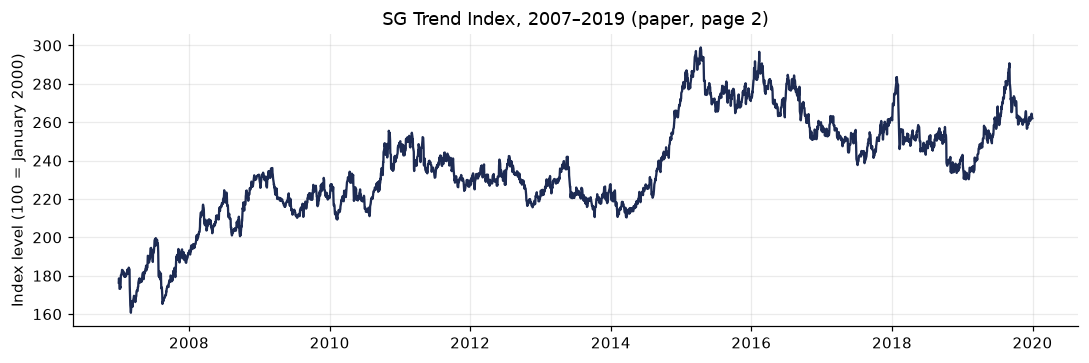

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.4))
level = K.window(sg_level, K.FULL_WINDOW)
ax.plot(level.index, level, color=COLORS['sg'])
ax.set(title='SG Trend Index, 2007–2019 (paper, page 2)', ylabel='Index level (100 = January 2000)')
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(OUTPUT / 'sg_trend_index.png', dpi=160)

## The model

Every week $t$, at the close of its last trading day, each market $i$ gets the signal

$$s_{i,t}=\max\!\Big(-c,\ \min\!\Big(c,\ \frac{\bar r_{i,t}(L)}{\sigma_{i,t}}\sqrt{L}\Big)\Big),\qquad \bar r_{i,t}(L)=\frac1L\sum_{j=0}^{L-1} r_{i,t-j},$$

where $r_{i,t}$ is the market's weekly return, $L$ the momentum lookback in weeks, $\sigma_{i,t}$ its weekly volatility (standard deviation of the last $V$ daily returns, times $\sqrt5$) and $c$ the cap. Below the cap, $s$ is the t-statistic of the average weekly return. The portfolio gives every market the same risk, ignoring correlations ("naive risk parity"), and holds its positions over the following week:

$$w_{i,t}=k\,\frac{s_{i,t}}{N\,\sigma^{\text{ann}}_{i,t}},\qquad R_{t+1}=\sum_{i=1}^{N} w_{i,t}\,r_{i,t+1},$$

with $N=16$, $\sigma^{\text{ann}}=\sigma\sqrt{52}$ and $w$ the notional held per dollar of capital. The leverage $k$ gives the portfolio SG Trend's volatility over 2007–2019, as the paper scales its model on in-sample results; it does not change any R². Replication quality is the $R^2$ of a regression of weekly SG Trend returns on $R$, the squared correlation.

The paper tests $L\in\{4,8,16,32,52\}$ weeks, $c\in\{0.01,0.5,1,1.5,2\}$ and $V\in\{20,30,60,90,180\}$ days: 125 combinations, written $L/c/V$ (for example 32/1/90). Its parameter list gives a cap of 0.0, which would hold nothing; its chart shows 0.01, which we use.

## 125 parameter combinations

We compute the R² of all 125 combinations over 2015–2019, the window of the paper's model charts, and over 2007–2019. The paper does not state the window of its R² charts; 2015–2019 is the one that reproduces them.

R² over 2015-2019 ranges from 0.11 to 0.67


,2015–2019,2007–2019
label,,
32/1/90,0.667,0.673
32/1/180,0.666,0.641
32/1.5/90,0.665,0.678
32/1.5/180,0.657,0.637
32/1/60,0.657,0.683


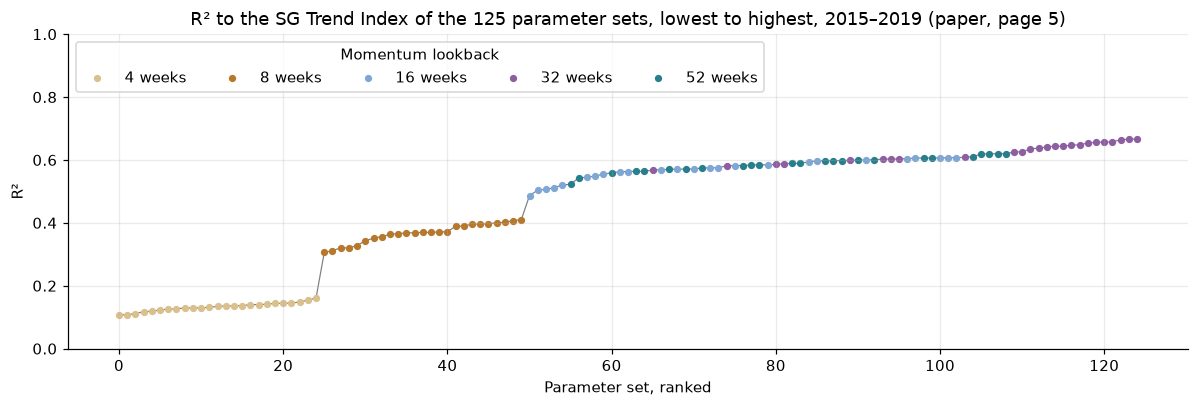

In [5]:
spans = {'2015–2019': K.PAPER_WINDOW, '2007–2019': K.FULL_WINDOW}
grid = K.r2_grid(weekly, vols, sg_weekly, spans)
ranked = grid.sort_values('2015–2019').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(ranked.index, ranked['2015–2019'], color='grey', lw=.8, zorder=0)
for lookback, group in ranked.groupby('lookback'):
    ax.scatter(group.index, group['2015–2019'], s=14, color=LOOKBACK_COLORS[lookback], label=f'{lookback} weeks')
ax.set(title='R² to the SG Trend Index of the 125 parameter sets, lowest to highest, 2015–2019 (paper, page 5)',
       xlabel='Parameter set, ranked', ylabel='R²', ylim=(0, 1))
ax.grid(alpha=.25)
ax.legend(title='Momentum lookback', ncol=5, loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT / 'r2_ranked.png', dpi=160)

print(f"R² over 2015-2019 ranges from {grid['2015–2019'].min():.2f} to {grid['2015–2019'].max():.2f}")
display(grid.nlargest(5, '2015–2019').set_index('label')[list(spans)].round(3))

replication  paper    gap
parameter  value                            
lookback   4.00          0.123   0.12  0.003
           8.00          0.395   0.40 -0.005
           16.00         0.607   0.61 -0.003
           32.00         0.667   0.67 -0.003
           52.00         0.620   0.62 -0.000
cap        0.01          0.599   0.62 -0.021
           0.50          0.647   0.65 -0.003
           1.00          0.667   0.67 -0.003
           1.50          0.665   0.67 -0.005
           2.00          0.656   0.66 -0.004
vol_window 20.00         0.608   0.60  0.008
           30.00         0.644   0.64  0.004
           60.00         0.657   0.66 -0.003
           90.00         0.667   0.67 -0.003
           180.00        0.666   0.67 -0.004

Mean absolute gap to the paper's charts: 0.005; largest: 0.021


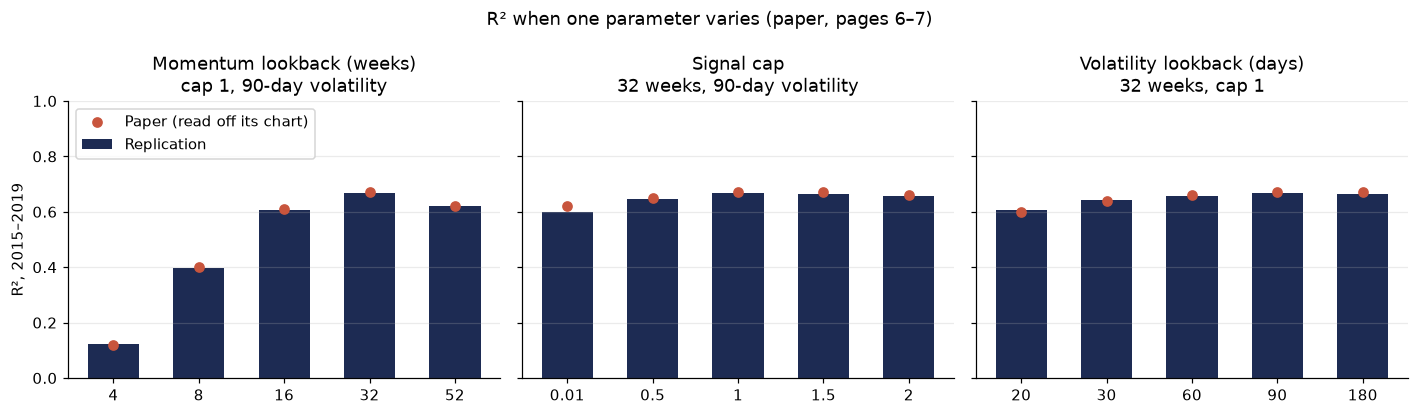

In [6]:
def sensitivity(param, fixed):
    sub = grid
    for name, value in fixed.items():
        sub = sub[sub[name] == value]
    return sub.set_index(param)['2015–2019']


panels = [('lookback', {'cap': 1.0, 'vol_window': 90}, 'Momentum lookback (weeks)\ncap 1, 90-day volatility'),
          ('cap', {'lookback': 32, 'vol_window': 90}, 'Signal cap\n32 weeks, 90-day volatility'),
          ('vol_window', {'lookback': 32, 'cap': 1.0}, 'Volatility lookback (days)\n32 weeks, cap 1')]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
rows = []
for ax, (param, fixed, title) in zip(axes, panels):
    ours, paper = sensitivity(param, fixed), pd.Series(K.PAPER_R2[param])
    x = np.arange(len(ours))
    ax.bar(x, ours.values, width=.6, color=COLORS['sg'], label='Replication')
    ax.scatter(x, paper.reindex(ours.index).values, color=COLORS['ensemble'], zorder=3,
               label='Paper (read off its chart)')
    ax.set_xticks(x, [f'{v:g}' for v in ours.index])
    ax.set(title=title, ylim=(0, 1))
    ax.grid(axis='y', alpha=.25)
    rows += [{'parameter': param, 'value': v, 'replication': ours[v], 'paper': paper[v]} for v in ours.index]
axes[0].set_ylabel('R², 2015–2019')
axes[0].legend(loc='upper left')
fig.suptitle('R² when one parameter varies (paper, pages 6–7)')
fig.tight_layout()
fig.savefig(OUTPUT / 'r2_sensitivity.png', dpi=160)

comparison = pd.DataFrame(rows).assign(gap=lambda d: d['replication'] - d['paper'])
display(comparison.set_index(['parameter', 'value']).round(3))
print(f"Mean absolute gap to the paper's charts: {comparison['gap'].abs().mean():.3f}; "
      f"largest: {comparison['gap'].abs().max():.3f}")

**Reading.** The grid reproduces the paper's three charts: the average gap to the values read off them is 0.005, the largest 0.02, at the 0.01 cap. Ranked, the R² run from 0.11 to 0.67 with the paper's two jumps, where the lookback goes from 4 to 8 weeks and from 8 to 16. The lookback matters most; across caps and volatility windows R² varies by at most 0.07, and the best set is the paper's 32/1/90. Over 2007–2019 the ranking is nearly the same (rank correlation 0.94 across the 125 sets), and the best sets again use 32 weeks, with R² up to 0.68.

## Three models and the ensemble

The paper fixes the cap at 1 and the volatility lookback at 90 days, and compares 16-, 32- and 52-week lookbacks. Its final model averages the three, since managers trade at several trend speeds (`K.ensemble`): each model is scaled to SG Trend's volatility, then their positions, and so their returns, are averaged.

In [7]:
models, ens_weights = K.ensemble(weekly, vols, sg_weekly)
paper = {'16/1/90': '0.61', '32/1/90': '0.67', '52/1/90': '0.62', 'Ensemble': 'above 0.75'}
table = pd.DataFrame({name: {f'R² {label}': K.r2(models[name], sg_weekly, span) for label, span in spans.items()}
                      for name in models}).T.round(3)
table['Paper'] = pd.Series(paper)
display(table)

,R² 2015–2019,R² 2007–2019,Paper
16/1/90,0.607,0.539,0.61
32/1/90,0.667,0.673,0.67
52/1/90,0.620,0.613,0.62
Ensemble,0.768,0.743,above 0.75


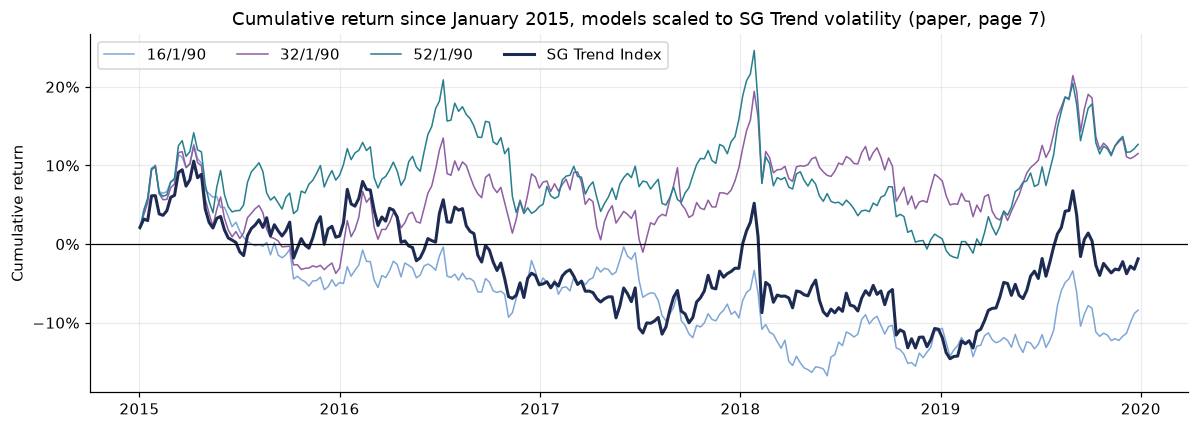

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, lookback in [('16/1/90', 16), ('32/1/90', 32), ('52/1/90', 52)]:
    ax.plot(cumulative(models[name], K.PAPER_WINDOW), color=COLORS[lookback], lw=1, label=name)
ax.plot(cumulative(sg_weekly, K.PAPER_WINDOW), color=COLORS['sg'], lw=2, label='SG Trend Index')
ax.axhline(0, color='black', lw=.8)
ax.yaxis.set_major_formatter(PCT)
ax.set(title='Cumulative return since January 2015, models scaled to SG Trend volatility (paper, page 7)',
       ylabel='Cumulative return')
ax.grid(alpha=.25)
ax.legend(ncol=4, loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT / 'three_models.png', dpi=160)

Cumulative return 2015-2019: Ensemble +5.6%, SG Trend Index -1.9%


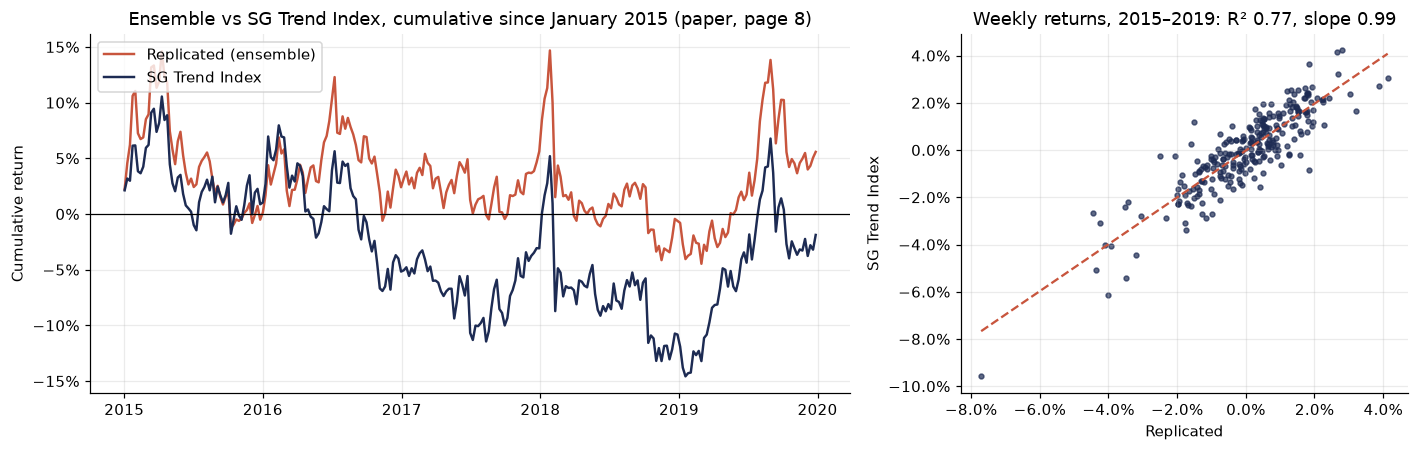

In [9]:
joint = K.window(pd.concat([models['Ensemble'], sg_weekly], axis=1, keys=['rep', 'sg']), K.PAPER_WINDOW).dropna()
slope, intercept = np.polyfit(joint['rep'], joint['sg'], 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.7, 1]})
ax1.plot(cumulative(models['Ensemble'], K.PAPER_WINDOW), color=COLORS['ensemble'], lw=1.6, label='Replicated (ensemble)')
ax1.plot(cumulative(sg_weekly, K.PAPER_WINDOW), color=COLORS['sg'], lw=1.6, label='SG Trend Index')
ax1.axhline(0, color='black', lw=.8)
ax1.yaxis.set_major_formatter(PCT)
ax1.set(title='Ensemble vs SG Trend Index, cumulative since January 2015 (paper, page 8)', ylabel='Cumulative return')
ax1.grid(alpha=.25)
ax1.legend(loc='upper left')
ax2.scatter(joint['rep'], joint['sg'], s=10, alpha=.7, color=COLORS['sg'])
xs = np.linspace(joint['rep'].min(), joint['rep'].max(), 50)
ax2.plot(xs, intercept + slope * xs, color=COLORS['ensemble'], ls='--')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set(title=f"Weekly returns, 2015–2019: R² {joint.corr().iloc[0, 1] ** 2:.2f}, slope {slope:.2f}",
        xlabel='Replicated', ylabel='SG Trend Index')
ax2.grid(alpha=.25)
fig.tight_layout()
fig.savefig(OUTPUT / 'ensemble.png', dpi=160)

ends = {name: cumulative(r, K.PAPER_WINDOW).iloc[-1] for name, r in
        [('Ensemble', models['Ensemble']), ('SG Trend Index', sg_weekly)]}
print('Cumulative return 2015-2019: ' + ', '.join(f'{k} {v:+.1%}' for k, v in ends.items()))

**Reading.** The single models explain 61%, 67% and 62% of weekly SG Trend returns over 2015–2019, the paper's values, and the ensemble 77% (74% over 2007–2019). The scatter's slope is 0.99: scaled to SG Trend's volatility, the replication moves one for one with the index. As in the paper's chart, the ensemble follows SG Trend's swings, including the early-2015 rally, the February 2018 reversal and the 2019 rally, but drifts above it: +5.6% over 2015–2019 against −1.9%. The replication pays no fees or trading costs.

## Trend followers' estimated exposures

The replication's weights $w_{i,t}$ are notional positions per dollar of capital: a weight of +100% in equities is a $1 long position per dollar invested in the benchmark. Summing them by sector gives the paper's sector exposures; multiplying them by $300bn, the Wall Street Journal estimate of trend-following assets that Kestner uses, gives dollar positions. These are the ensemble's weights, scaled like its returns to SG Trend's volatility.

sector,Equities,Rates,Currencies,Commodities
min,-48%,-180%,-122%,-43%
median,32%,146%,-41%,5%
max,111%,381%,121%,42%


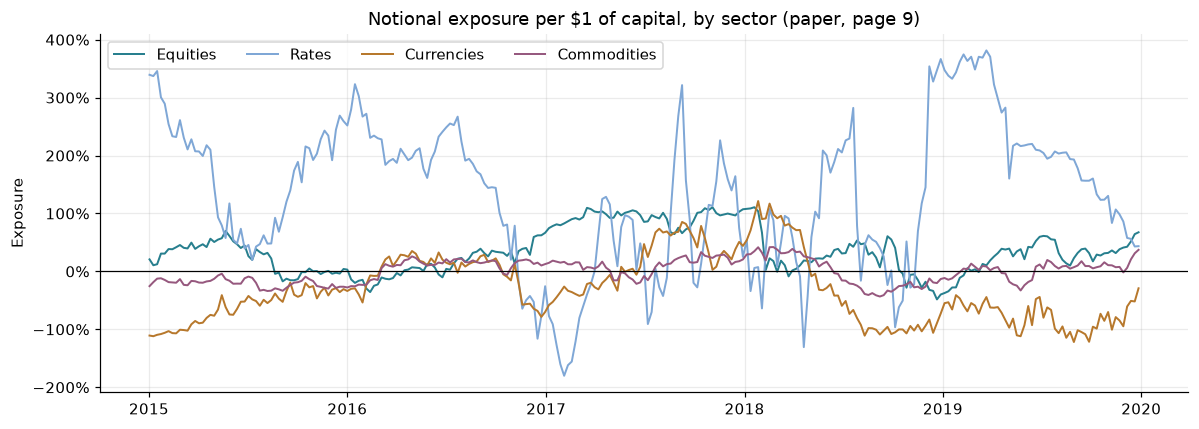

In [10]:
sectors = K.window(K.sector_exposure(ens_weights, markets), K.PAPER_WINDOW)

fig, ax = plt.subplots(figsize=(11, 4))
for sector in K.SECTORS:
    ax.plot(sectors.index, sectors[sector], color=COLORS[sector], lw=1.3, label=sector)
ax.axhline(0, color='black', lw=.8)
ax.yaxis.set_major_formatter(PCT)
ax.set(title='Notional exposure per $1 of capital, by sector (paper, page 9)', ylabel='Exposure')
ax.grid(alpha=.25)
ax.legend(ncol=4, loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT / 'sector_exposure.png', dpi=160)

display(sectors.describe().loc[['min', '50%', 'max']].rename(index={'50%': 'median'}).map('{:.0%}'.format))

,ES,Z,VG,NK,All equities
min,-33.0,-45.0,-45.0,-22.0,-145.0
median,36.0,26.0,17.0,18.0,96.0
max,140.0,100.0,83.0,82.0,332.0


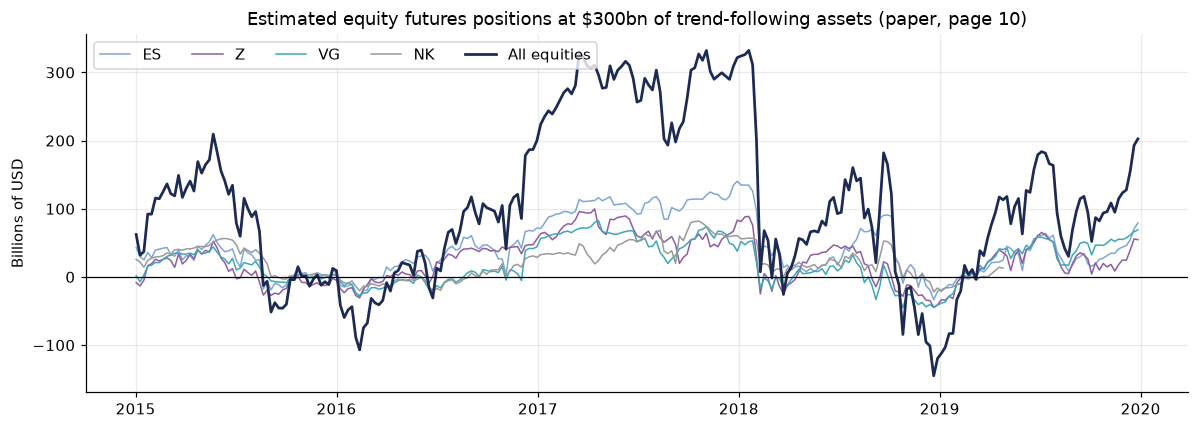

In [11]:
EQUITIES = ['ES', 'Z', 'VG', 'NK']
dollars = K.window(ens_weights[EQUITIES] * K.AUM_USD / 1e9, K.PAPER_WINDOW)
dollars['All equities'] = dollars[EQUITIES].sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
for market, color in zip(EQUITIES, ['#7fa7d6', '#8e5ea2', '#3fa7b5', '#9a9a9a']):
    ax.plot(dollars.index, dollars[market], color=color, lw=1, label=market)
ax.plot(dollars.index, dollars['All equities'], color=COLORS['sg'], lw=1.8, label='All equities')
ax.axhline(0, color='black', lw=.8)
ax.set(title='Estimated equity futures positions at $300bn of trend-following assets (paper, page 10)',
       ylabel='Billions of USD')
ax.grid(alpha=.25)
ax.legend(ncol=5, loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT / 'equity_dollar_exposure.png', dpi=160)

display(dollars.describe().loc[['min', '50%', 'max']].rename(index={'50%': 'median'}).round(0))

The paper's case for replication is that a rolling regression of SG Trend returns on market returns lags. We regress weekly SG Trend returns on S&P 500 futures returns over rolling 20-week windows, as Kestner does; the slope is the implied notional exposure to the S&P 500. To measure the lag, we correlate the regression beta at week $t$ with the replication's equity exposure $k$ weeks earlier, over 2007–2019.

Correlation peaks at k = 12 weeks (0.73), against 0.54 at k = 0
Typical weekly change, 2007-2019: regression beta 11%, replication equity exposure 10%


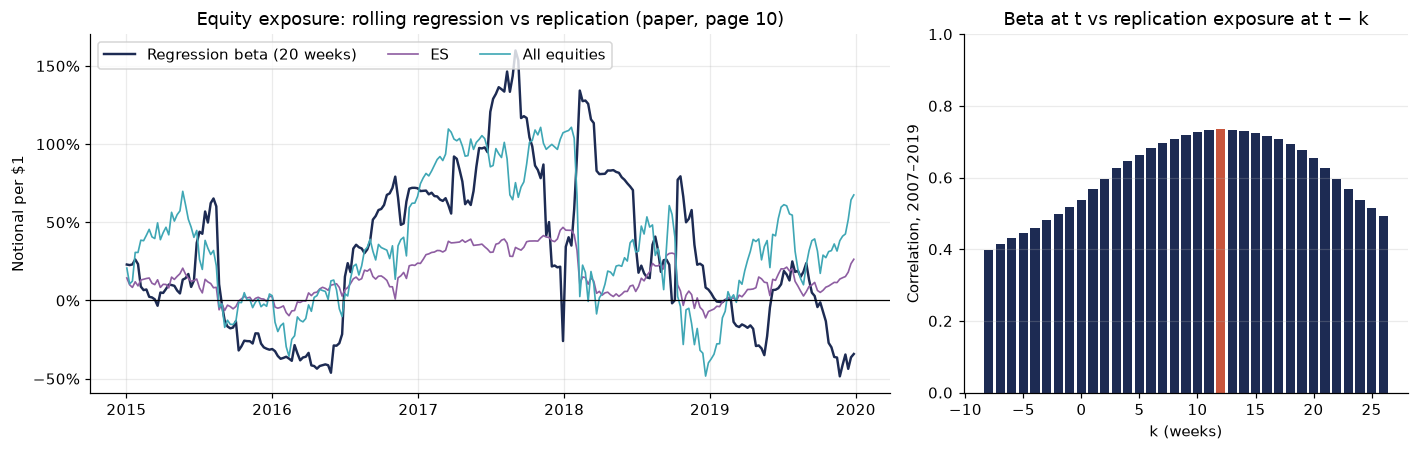

In [12]:
beta = K.rolling_beta(sg_weekly, weekly['ES'], weeks=20)
equity_exposure = K.sector_exposure(ens_weights, markets)['Equities']
exposures = pd.concat({'Regression beta (20 weeks)': beta, 'ES': ens_weights['ES'],
                       'All equities': equity_exposure}, axis=1)
lags = K.lagged_correlation(K.window(beta, K.FULL_WINDOW), equity_exposure, range(-8, 27))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.8, 1]})
shown = K.window(exposures, K.PAPER_WINDOW)
for column, color, lw in zip(shown, [COLORS['sg'], '#8e5ea2', '#3fa7b5'], [1.6, 1.1, 1.1]):
    ax1.plot(shown.index, shown[column], color=color, lw=lw, label=column)
ax1.axhline(0, color='black', lw=.8)
ax1.yaxis.set_major_formatter(PCT)
ax1.set(title='Equity exposure: rolling regression vs replication (paper, page 10)', ylabel='Notional per $1')
ax1.grid(alpha=.25)
ax1.legend(ncol=3, loc='upper left')
ax2.bar(lags.index, lags.values, color=COLORS['sg'])
ax2.bar(lags.idxmax(), lags.max(), color=COLORS['ensemble'])
ax2.set(title='Beta at t vs replication exposure at t − k', xlabel='k (weeks)',
        ylabel='Correlation, 2007–2019', ylim=(0, 1))
ax2.grid(axis='y', alpha=.25)
fig.tight_layout()
fig.savefig(OUTPUT / 'regression_vs_replication.png', dpi=160)

changes = K.window(exposures, K.FULL_WINDOW).diff().std()
print(f"Correlation peaks at k = {lags.idxmax()} weeks ({lags.max():.2f}), against {lags[0]:.2f} at k = 0")
print(f"Typical weekly change, 2007-2019: regression beta {changes['Regression beta (20 weeks)']:.0%}, "
      f"replication equity exposure {changes['All equities']:.0%}")

**Reading.** The exposures look like the paper's charts. Bonds carry the largest notional (median 146% of capital, up to 381%): they are the least volatile futures, so equal risk needs the largest positions. Currencies range from −122% to +121%, equities from −48% to +111%, and commodities stay within ±43%. In dollars, estimated trend-follower positions in the four equity markets peak at $332bn on 19 January 2018, just before the February 2018 sell-off, and are shortest at −$145bn in December 2018; S&P 500 futures alone reach $140bn.

The regression beta tracks the same equity exposure, but late. Its correlation with the replication's exposure rises from 0.54 in the same week to 0.73 when the exposure is taken 12 weeks earlier, a little over half the 20-week window, as expected from a regression that averages old and new positions. It is barely noisier, though: its typical weekly change is 11 points against 10 for the replication. On our data the paper's lag argument holds; its smoothness argument holds only weakly.

## Out of sample, 2020–2026

The paper's sample ends in 2019. We run its final model unchanged, with the same 16-, 32- and 52-week lookbacks, cap 1, 90-day volatility and leverage fitted on 2007–2019, from January 2020 to the last SG Trend observation.

,16/1/90,32/1/90,52/1/90,Ensemble
2020,0.37,0.42,0.63,0.56
2021,0.38,0.60,0.67,0.73
2022,0.71,0.71,0.75,0.77
2023,0.46,0.37,0.36,0.63
2024,0.48,0.49,0.61,0.65
2025,0.54,0.56,0.62,0.63
2026,0.53,0.55,0.34,0.53
2020–2026-08,0.47,0.51,0.58,0.64
2015–2019 (in sample),0.61,0.67,0.62,0.77


Cumulative return 2020 to 2026-08: Ensemble +26.9%, SG Trend Index +62.6%


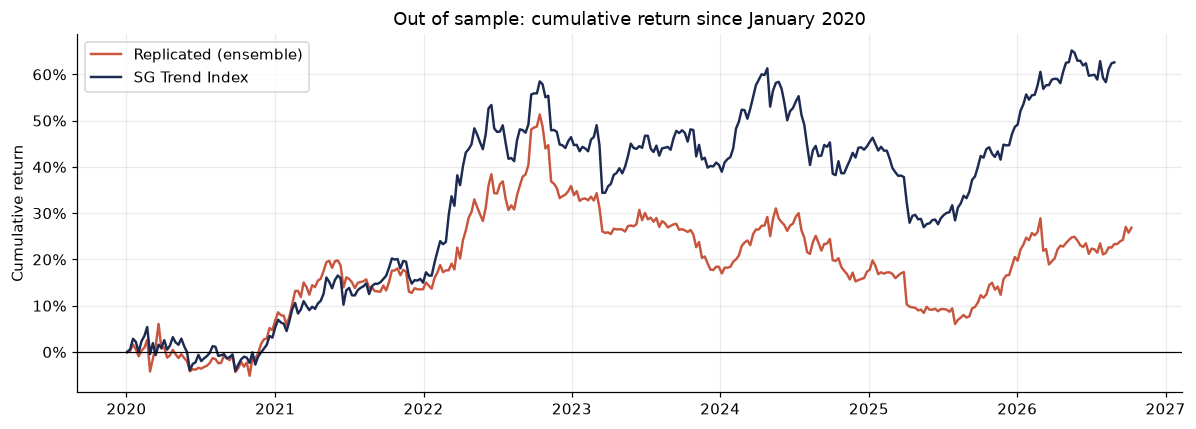

In [13]:
oos = pd.DataFrame({name: K.yearly_r2(models[name], sg_weekly, range(2020, sg_level.index[-1].year + 1))
                    for name in models})
oos.index = oos.index.astype(str)
oos.loc[f"2020–{sg_level.index[-1]:%Y-%m}"] = [K.r2(models[name], sg_weekly, K.OOS_WINDOW) for name in models]
oos.loc['2015–2019 (in sample)'] = [K.r2(models[name], sg_weekly, K.PAPER_WINDOW) for name in models]
display(oos.round(2))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cumulative(models['Ensemble'], K.OOS_WINDOW), color=COLORS['ensemble'], lw=1.6, label='Replicated (ensemble)')
ax.plot(cumulative(sg_weekly, K.OOS_WINDOW), color=COLORS['sg'], lw=1.6, label='SG Trend Index')
ax.axhline(0, color='black', lw=.8)
ax.yaxis.set_major_formatter(PCT)
ax.set(title='Out of sample: cumulative return since January 2020', ylabel='Cumulative return')
ax.grid(alpha=.25)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT / 'out_of_sample.png', dpi=160)

ends = {name: cumulative(r, K.OOS_WINDOW).iloc[-1] for name, r in
        [('Ensemble', models['Ensemble']), ('SG Trend Index', sg_weekly)]}
print(f"Cumulative return 2020 to {sg_level.index[-1]:%Y-%m}: " + ', '.join(f'{k} {v:+.1%}' for k, v in ends.items()))

**Reading.** After the paper's sample, the unchanged model still explains 64% of weekly SG Trend returns: less than in sample (77%), but at least 53% in every year, and 77% in 2022, SG Trend's best year since 2015 (+27%). Over the whole period the ensemble beats each single model (64% against 47% to 58%). It earns less than the index, +27% against +63% since January 2020. Much of the gap is likely interest on cash: CTA funds earn it on their collateral, futures excess returns leave it out, and rates rose from 2022. It does not affect R².

## Choices the paper leaves open

Kestner does not say when his positions roll, or how the ensemble averages its models. The table shows how much each choice matters; the leverage window, the third open choice, does not affect R².

In [14]:
rows = []
for roll in (ROLL_DAYS, 0):
    d = daily if roll == ROLL_DAYS else K.daily_returns(DATA, markets, roll_days=roll)
    wk = K.weekly_returns(d)
    vv = {90: K.weekly_vol(d, 90)}
    scaled = K.ensemble(wk, vv, sg_weekly)[0]['Ensemble']
    unscaled = pd.concat([K.model(wk, vv, lookback)[0] for lookback in K.ENSEMBLE], axis=1).mean(axis=1)
    for averaging, ret in [('models scaled to SG volatility, then averaged', scaled),
                           ('unscaled models averaged', unscaled)]:
        rows.append({'roll': f'{roll} trading days before expiry' if roll else 'at expiry (Bloomberg generic)',
                     'ensemble': averaging,
                     **{f'R² {label}': K.r2(ret, sg_weekly, span)
                        for label, span in {**spans, '2020–2026': K.OOS_WINDOW}.items()}})
display(pd.DataFrame(rows).set_index(['roll', 'ensemble']).round(3))

R² 2015–2019  \
roll                          ensemble                                                      
5 trading days before expiry  models scaled to SG volatility, then averaged         0.768   
                              unscaled models averaged                              0.770   
at expiry (Bloomberg generic) models scaled to SG volatility, then averaged         0.768   
                              unscaled models averaged                              0.770   

                                                                             R² 2007–2019  \
roll                          ensemble                                                      
5 trading days before expiry  models scaled to SG volatility, then averaged         0.743   
                              unscaled models averaged                              0.744   
at expiry (Bloomberg generic) models scaled to SG volatility, then averaged         0.748   
                              unscaled models averaged                              0.749   

                                                                             R² 2020–2026  
roll                          ensemble                                                     
5 trading days before expiry  models scaled to SG volatility, then averaged         0.639  
                              unscaled models averaged                              0.624  
at expiry (Bloomberg generic) models scaled to SG volatility, then averaged         0.622  
                              unscaled models averaged                              0.608

**Reading.** Neither choice matters in the paper's windows: rolling at expiry instead of five days early, or averaging unscaled models, moves R² by at most 0.005. Out of sample, rolling early and scaling before averaging each add about 0.015 (0.639 against 0.608 to 0.624).

## Save results

In [15]:
grid.to_csv(OUTPUT / 'r2_grid.csv', index=False)
models.join(sg_weekly.rename('SG Trend Index')).to_csv(OUTPUT / 'weekly_returns.csv')
ens_weights.to_csv(OUTPUT / 'ensemble_weights.csv')
K.sector_exposure(ens_weights, markets).to_csv(OUTPUT / 'sector_exposure.csv')
oos.to_csv(OUTPUT / 'out_of_sample_r2.csv')

## References

- Kestner, L. N. (2020), *Replicating CTA Positioning: An Improved Method*, Statistically Applied Trading, [SSRN 3674828](https://ssrn.com/abstract=3674828).
- Société Générale Prime Services, [SG Trend Index methodology](https://wholesale.banking.societegenerale.com/fileadmin/indices_feeds/SG_Trend_Index_Methodology.pdf).
- Data: `working_ideas/data_required/` (README, *Cross-asset CTA data*) and `paper_replication/data_required/sg_cta_indices.csv`.